In [1]:
import os
import sys

# Add local directories to sys.path
sys.path.append(os.path.abspath("../data"))
sys.path.append(os.path.abspath("../network"))

import torch
import numpy as np
import matplotlib.pyplot as plt

# Local imports
import load
from load import ParallelMelspecDataset, collate_fn
from modules import KameBlock
from kenku import KenkuTeacher

from typing import Union, List, Tuple, Optional

from torch import nn, Tensor
from torch.utils.data import DataLoader

from tqdm import tqdm

torch.set_default_device("cuda:0")

In [2]:
rng = np.random.default_rng(42)
batch_size = 16
lrate = 1e-3
rf = 1
in_ch = 80 * rf
conv_ch = 80 * rf
att_ch = 80 * rf
out_ch = 80 * rf
embed_ch = 2
num_classes = 2

dataset = ParallelMelspecDataset(melspec_dir = "../../Data/processed/VCTK/melspec", 
                                 transcript_dir = "../../Data/processed/VCTK/transcript_standardized",
                                 speaker_properties_path = "../../Data/processed/VCTK/speaker_properties.csv",
                                 min_samples_per_sentence = 10,
                                 rng = rng)
# dataset.preload_melspecs()

loader = DataLoader(
  dataset, 
  batch_size=batch_size,
  shuffle=True,
  num_workers=0,  # Set to 0 or os.cpu_count() depending on the environment
  drop_last=True,
  collate_fn=collate_fn,
  generator=torch.Generator(device='cuda').manual_seed(42),
)

model = KenkuTeacher(in_ch, conv_ch, att_ch, out_ch, embed_ch, num_classes)

optimizer = torch.optim.Adam(model.parameters(), lr=lrate, betas=(0.9, 0.999))

===== Epoch 0 =====


  0%|          | 0/845 [00:00<?, ?it/s]

RuntimeError: Expected a 'cuda' device type for generator but found 'cpu'

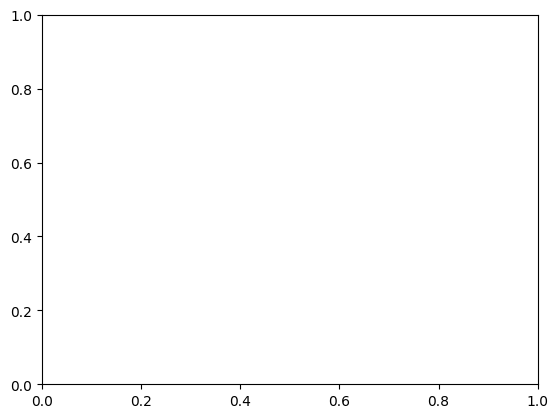

In [3]:
epochs = 15
losses = []

save_every = 999
plot_every = 20


fig, ax = plt.subplots()

for epoch in range(epochs):
  print(f"===== Epoch {epoch} =====")
  
  for bi, batch in tqdm(enumerate(loader), total=len(dataset) // batch_size):
    loss = model.calc_loss(*batch, reduction_factor=rf)
    
    loss_val = loss.item()
    losses.append(loss_val)
    
    model.zero_grad()
    loss.backward()
    optimizer.step()
    
    if bi > 0 and bi % plot_every == 0:
      ax.clear()
      ax.set(xlabel='batch', ylabel='MSE loss')
      ax.plot(range(len(losses)), losses, label='training loss')
      display(fig, clear=True)
  
    if bi > 0  and bi % save_every == 0 or bi == (len(dataset) // batch_size) - 1:
      torch.save(model.state_dict(), f'./checkpoints/test_model_ep{epoch}.pt')
      with open(f'./checkpoints/losses_ep{epoch}.txt', 'w') as file:
        file.write(str(list(losses)))
  
  print('\n')
    

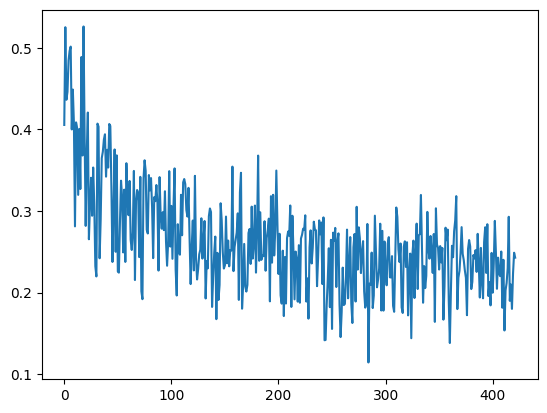

In [4]:
# import matplotlib.pyplot as plt

# plt.plot(range(len(losses)), losses)
# plt.show()

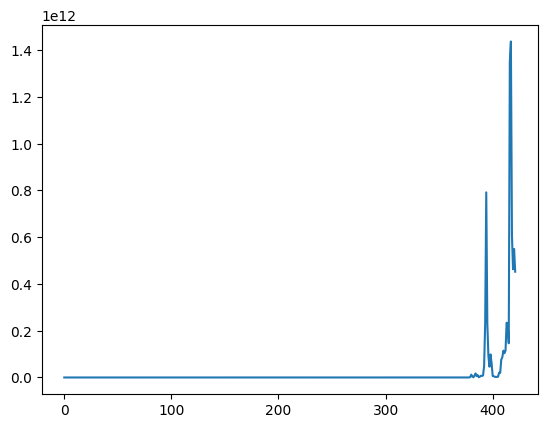

In [1]:
import matplotlib.pyplot as plt

losses = []
with open('./checkpoints/losses_ep0.txt' ,'r') as file:
  losses  = list(map(float, file.readline()[1:-2].split(', ')))
  
plt.plot(range(len(losses)), losses)

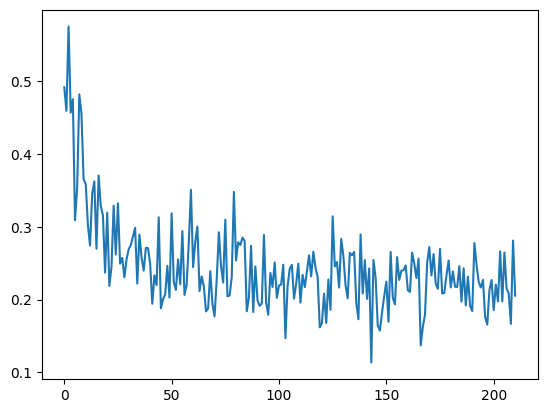

In [2]:
# import matplotlib.pyplot as plt

# losses = []
# with open('./checkpoints/losses_ep0.txt' ,'r') as file:
#   losses  = list(map(float, file.readline()[1:-2].split(', ')))
  
# plt.plot(range(len(losses)), losses)